========== Ergebnisse der Pumpenanalyse ==========
Verwendete Kennlinie: 269 mm
Markierter Betriebspunkt: V = 250 m³/h, H = 20 m
Messzeitraum: 2024-04-01 00:00:00 bis 2024-04-01 23:59:00
Anzahl Messwerte: 1440

Mittlerer Volumenstrom: 253.39 m³/h
Mittlere Förderhöhe: 19.73 m

Energieverbrauch an der Pumpenwelle: 469.69 kWh
Elektrischer Energieverbrauch inkl. Motor: 501.80 kWh
Hydraulisch genutzte Energie: 316.61 kWh

Durchschnittlicher Pumpenwirkungsgrad: 67.41 %
Durchschnittlicher Gesamtwirkungsgrad inkl. Motor: 63.09 %

Nicht hydraulisch genutzte Energie, nur Pumpe: 153.08 kWh
Nicht hydraulisch genutzte Energie inkl. Motor: 185.20 kWh


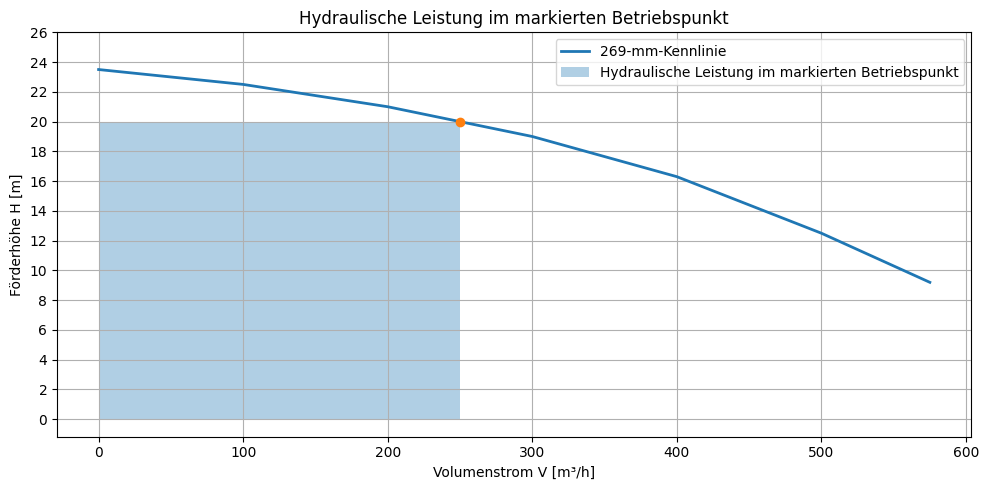

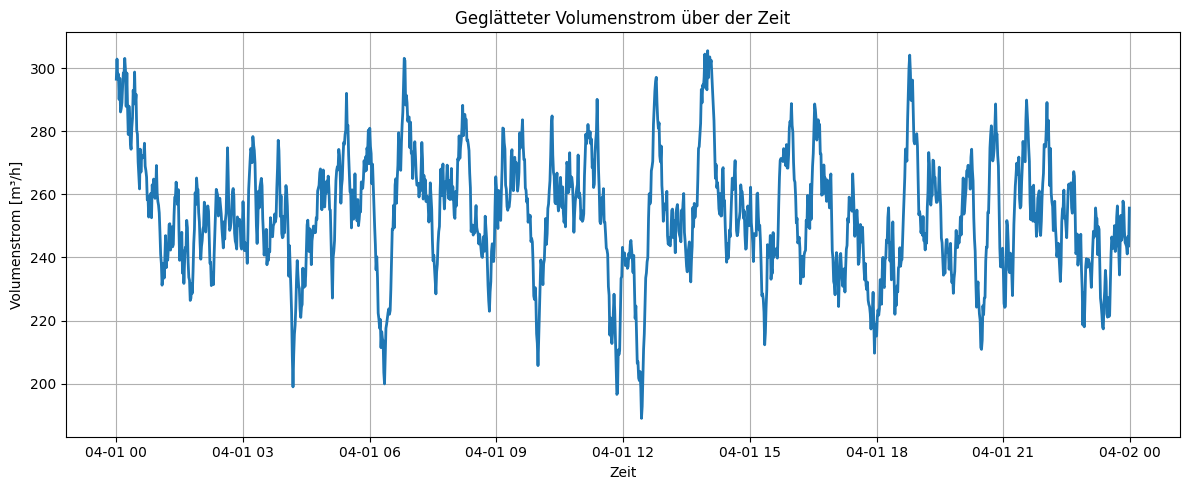

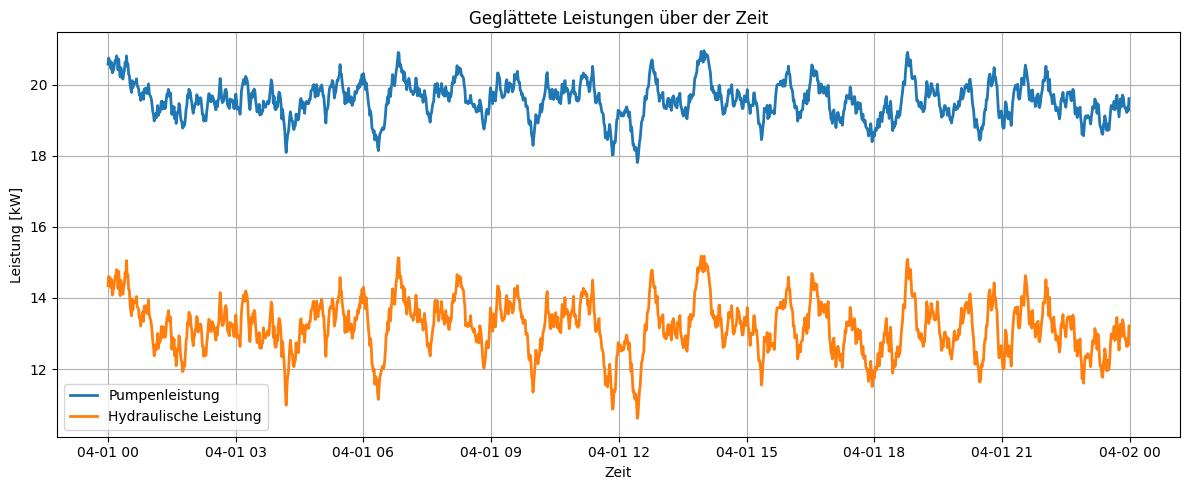

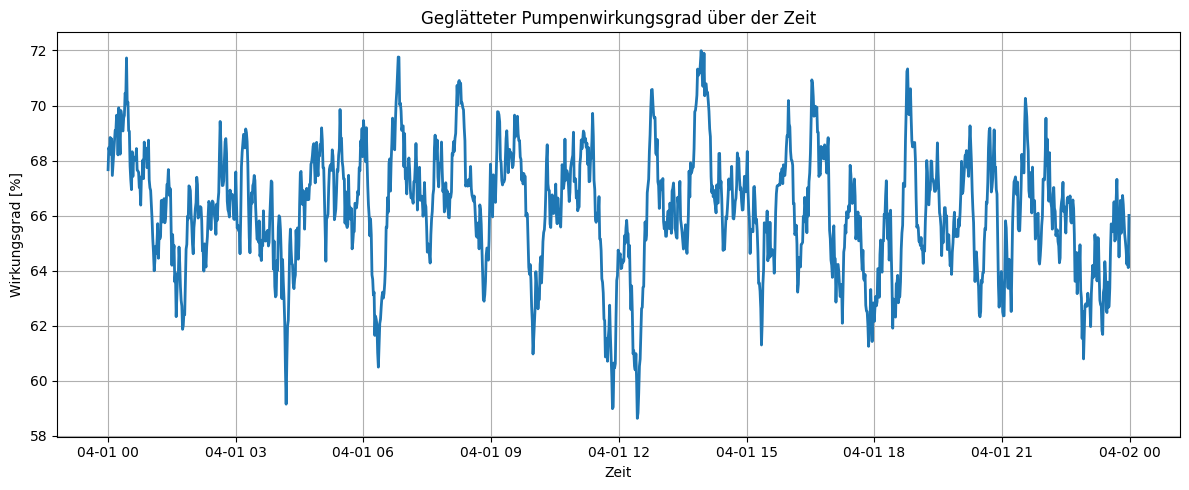

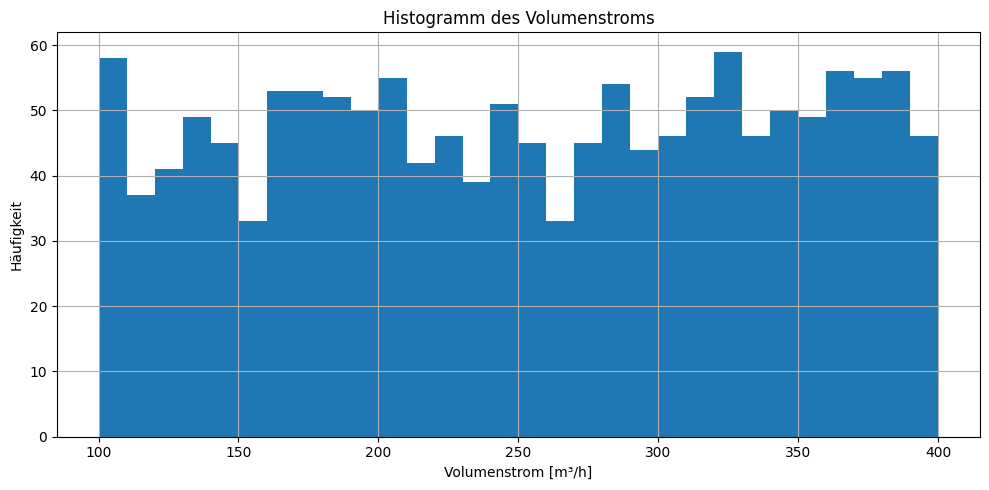

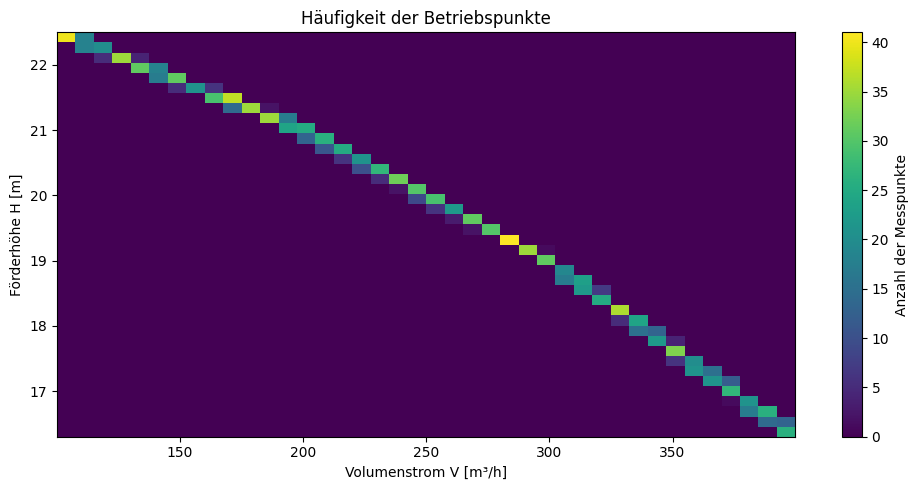

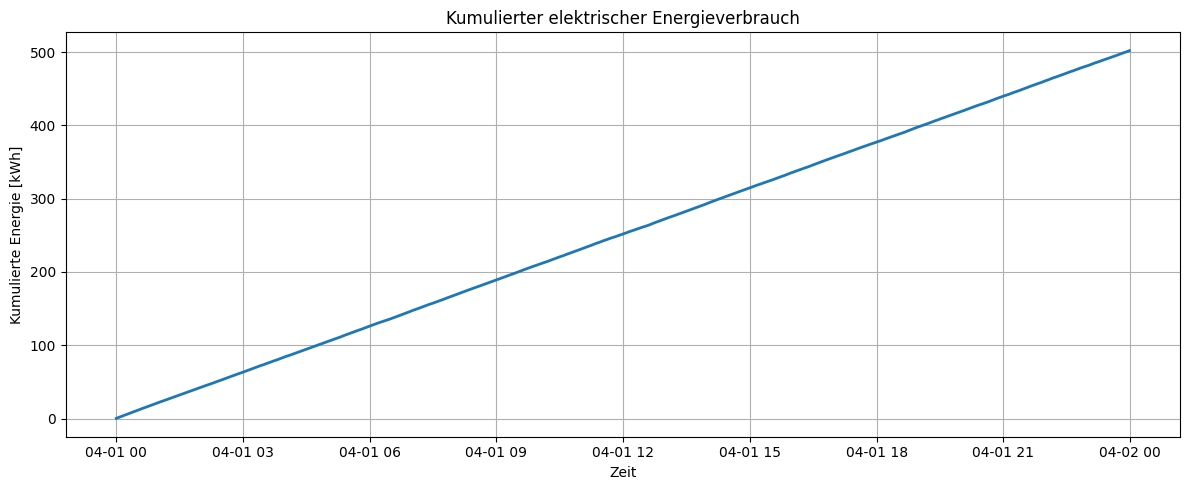

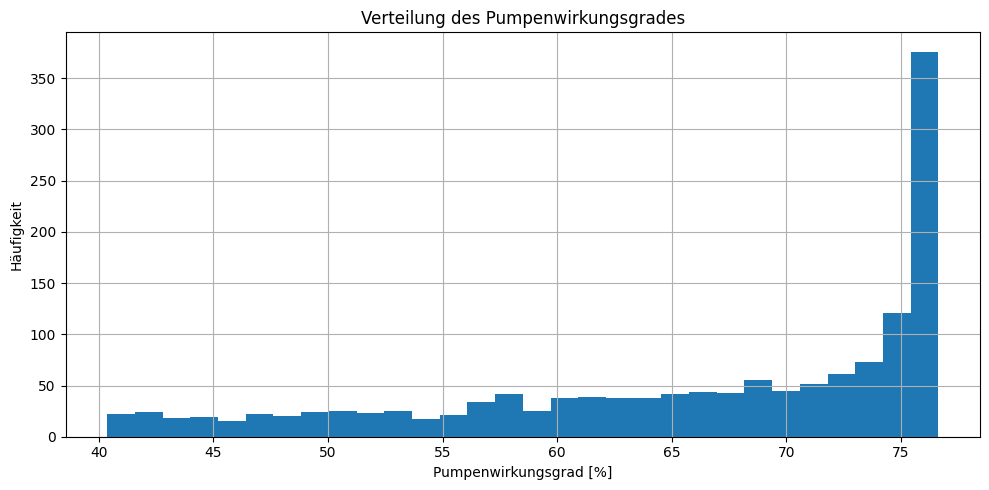

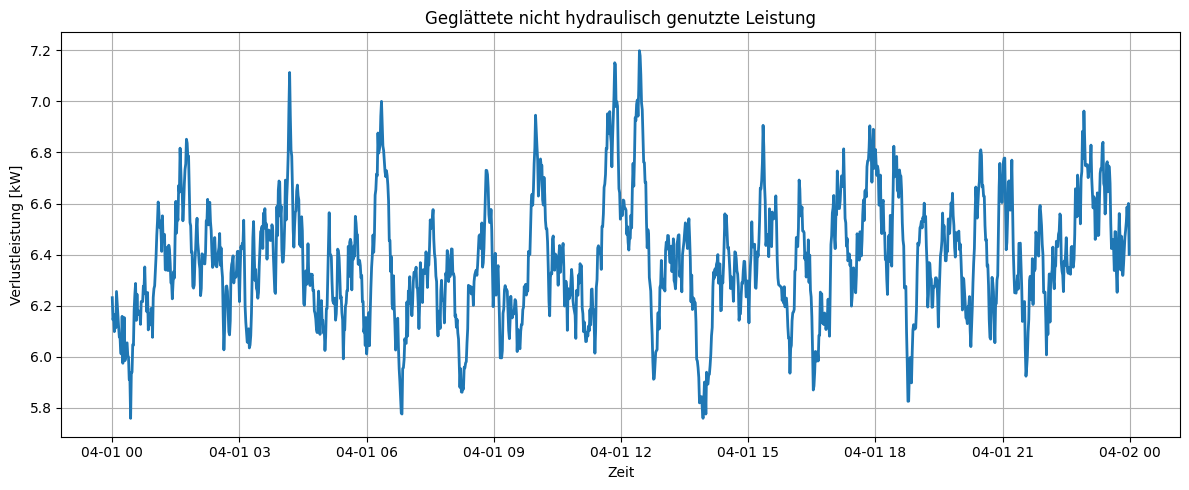

In [1]:
# ============================================================
# Pumpenanalyse mit CSV-Messdaten
# ============================================================
# Grundlage:
# - Wasser wird gefördert.
# - Der Volumenstrom wird nach der Pumpe gemessen.
# - Die Messwerte liegen in einer CSV-Datei.
# - Es wird die 269-mm-Kennlinie verwendet.
# - Ein Kästchen im Diagramm entspricht 2 m Förderhöhe.
# - Der markierte Betriebspunkt wird verwendet:
#   V = 250 m³/h, H = 20 m.
# ============================================================


# ------------------------------------------------------------
# 1. Bibliotheken importieren
# ------------------------------------------------------------

import pandas as pd
# Zum Einlesen und Bearbeiten der CSV-Datei.

import numpy as np
# Für mathematische Berechnungen.

import matplotlib.pyplot as plt
# Für Diagramme.


# ------------------------------------------------------------
# 2. Konstanten definieren
# ------------------------------------------------------------

CSV_DATEI = "volume_flow_data.csv"
# Name der CSV-Datei.

RHO_WASSER = 1000
# Dichte von Wasser [kg/m³].

G = 9.81
# Erdbeschleunigung [m/s²].

ETA_MOTOR = 0.936
# Motorwirkungsgrad aus Datenblatt.

WINDOW = 20
# Fenstergröße für die Glättung.

D_LAUFRAD = 269
# Laufraddurchmesser [mm].

V_MARKIERT = 250
# Markierter Betriebspunkt, Volumenstrom [m³/h].

H_MARKIERT = 20
# Markierter Betriebspunkt, Förderhöhe [m].


# ------------------------------------------------------------
# 3. 269-mm-Kennlinie aus dem Diagramm definieren
# ------------------------------------------------------------

v_curve = np.array([0, 100, 200, 250, 300, 400, 500, 575])
# Volumenstromwerte der 269-mm-Kennlinie [m³/h].

h_curve = np.array([23.5, 22.5, 21.0, 20.0, 19.0, 16.3, 12.5, 9.2])
# Förderhöhe der 269-mm-Kennlinie [m].

p_abs_curve = np.array([13.5, 15.2, 18.2, 19.7, 21.0, 23.2, 24.7, 25.0])
# Aufgenommene Pumpenleistung der 269-mm-Kennlinie [kW].


# ------------------------------------------------------------
# 4. CSV-Datei einlesen
# ------------------------------------------------------------

df = pd.read_csv(CSV_DATEI)
# CSV-Datei wird eingelesen.

df["Timestamp"] = pd.to_datetime(df["Timestamp"])
# Zeitspalte wird in ein Datumsformat umgewandelt.

df["V_m3h"] = df["Volume Flow (m^3/h)"]
# Volumenstrom aus der CSV wird übernommen.

df["V_m3s"] = df["V_m3h"] / 3600
# Volumenstrom wird von m³/h in m³/s umgerechnet.


# ------------------------------------------------------------
# 5. Zeitabstände berechnen
# ------------------------------------------------------------

df["dt_h"] = df["Timestamp"].diff().dt.total_seconds() / 3600
# Zeitabstand zwischen zwei Messpunkten in Stunden berechnen.

df.loc[df["dt_h"].isna(), "dt_h"] = df["dt_h"].median()
# Fehlender erster Zeitabstand wird ersetzt.


# ------------------------------------------------------------
# 6. Förderhöhe und Pumpenleistung bestimmen
# ------------------------------------------------------------

df["H_m"] = np.interp(df["V_m3h"], v_curve, h_curve)
# Förderhöhe aus der 269-mm-Kennlinie bestimmen.

df["P_abs_kW"] = np.interp(df["V_m3h"], v_curve, p_abs_curve)
# Aufgenommene Pumpenleistung aus der Kennlinie bestimmen.


# ------------------------------------------------------------
# 7. Hydraulische Leistung und Wirkungsgrad berechnen
# ------------------------------------------------------------

# Formel:
# P_hyd = rho * g * V * H

df["P_hyd_kW"] = RHO_WASSER * G * df["V_m3s"] * df["H_m"] / 1000
# Hydraulische Leistung berechnen.

df["P_el_kW"] = df["P_abs_kW"] / ETA_MOTOR
# Elektrische Leistung inklusive Motorverluste berechnen.

df["eta_pumpe"] = df["P_hyd_kW"] / df["P_abs_kW"]
# Pumpenwirkungsgrad berechnen.

df["eta_gesamt"] = df["P_hyd_kW"] / df["P_el_kW"]
# Gesamtwirkungsgrad inklusive Motor berechnen.

df["eta_pumpe"] = df["eta_pumpe"].clip(lower=0, upper=1)
# Pumpenwirkungsgrad auf 0 bis 100 % begrenzen.

df["eta_gesamt"] = df["eta_gesamt"].clip(lower=0, upper=1)
# Gesamtwirkungsgrad auf 0 bis 100 % begrenzen.


# ------------------------------------------------------------
# 8. Energien berechnen
# ------------------------------------------------------------

df["E_abs_kWh"] = df["P_abs_kW"] * df["dt_h"]
# Energie an der Pumpenwelle berechnen.

df["E_el_kWh"] = df["P_el_kW"] * df["dt_h"]
# Elektrische Energie berechnen.

df["E_hyd_kWh"] = df["P_hyd_kW"] * df["dt_h"]
# Hydraulisch genutzte Energie berechnen.

energie_pumpe = df["E_abs_kWh"].sum()
# Energie an der Pumpenwelle aufsummieren.

energie_elektrisch = df["E_el_kWh"].sum()
# Elektrische Energie aufsummieren.

energie_hydraulisch = df["E_hyd_kWh"].sum()
# Hydraulische Nutzenergie aufsummieren.

ungenutzte_energie_pumpe = energie_pumpe - energie_hydraulisch
# Nicht hydraulisch genutzte Energie der Pumpe berechnen.

ungenutzte_energie_gesamt = energie_elektrisch - energie_hydraulisch
# Nicht hydraulisch genutzte Energie inklusive Motor berechnen.

eta_pumpe_mittel = energie_hydraulisch / energie_pumpe
# Durchschnittlichen Pumpenwirkungsgrad berechnen.

eta_gesamt_mittel = energie_hydraulisch / energie_elektrisch
# Durchschnittlichen Gesamtwirkungsgrad berechnen.


# ------------------------------------------------------------
# 9. Messdaten glätten
# ------------------------------------------------------------

df["V_smooth"] = df["V_m3h"].rolling(WINDOW, center=True, min_periods=1).mean()
# Volumenstrom glätten.

df["P_abs_smooth"] = df["P_abs_kW"].rolling(WINDOW, center=True, min_periods=1).mean()
# Pumpenleistung glätten.

df["P_hyd_smooth"] = df["P_hyd_kW"].rolling(WINDOW, center=True, min_periods=1).mean()
# Hydraulische Leistung glätten.

df["eta_smooth"] = (df["eta_pumpe"] * 100).rolling(WINDOW, center=True, min_periods=1).mean()
# Wirkungsgrad glätten.


# ------------------------------------------------------------
# 10. Ergebnisse ausgeben
# ------------------------------------------------------------

print("========== Ergebnisse der Pumpenanalyse ==========")
# Überschrift der Ergebnisübersicht ausgeben.

print(f"Verwendete Kennlinie: {D_LAUFRAD} mm")
# Verwendeten Laufraddurchmesser ausgeben.

print(f"Markierter Betriebspunkt: V = {V_MARKIERT} m³/h, H = {H_MARKIERT} m")
# Markierten Betriebspunkt ausgeben.

print(f"Messzeitraum: {df['Timestamp'].min()} bis {df['Timestamp'].max()}")
# Anfang und Ende des Messzeitraums ausgeben.

print(f"Anzahl Messwerte: {len(df)}")
# Anzahl der Messwerte ausgeben.

print()
# Leerzeile für bessere Lesbarkeit ausgeben.

print(f"Mittlerer Volumenstrom: {df['V_m3h'].mean():.2f} m³/h")
# Durchschnittlichen Volumenstrom ausgeben.

print(f"Mittlere Förderhöhe: {df['H_m'].mean():.2f} m")
# Durchschnittliche Förderhöhe ausgeben.

print()
# Leerzeile ausgeben.

print(f"Energieverbrauch an der Pumpenwelle: {energie_pumpe:.2f} kWh")
# Aufsummierte Energie an der Pumpenwelle ausgeben.

print(f"Elektrischer Energieverbrauch inkl. Motor: {energie_elektrisch:.2f} kWh")
# Elektrischen Energieverbrauch inklusive Motorverluste ausgeben.

print(f"Hydraulisch genutzte Energie: {energie_hydraulisch:.2f} kWh")
# Tatsächlich hydraulisch genutzte Energie ausgeben.

print()
# Leerzeile ausgeben.

print(f"Durchschnittlicher Pumpenwirkungsgrad: {eta_pumpe_mittel * 100:.2f} %")
# Durchschnittlichen Wirkungsgrad der Pumpe ausgeben.

print(f"Durchschnittlicher Gesamtwirkungsgrad inkl. Motor: {eta_gesamt_mittel * 100:.2f} %")
# Durchschnittlichen Gesamtwirkungsgrad inklusive Motor ausgeben.

print()
# Leerzeile ausgeben.

print(f"Nicht hydraulisch genutzte Energie, nur Pumpe: {ungenutzte_energie_pumpe:.2f} kWh")
# Energieverluste der Pumpe ausgeben.

print(f"Nicht hydraulisch genutzte Energie inkl. Motor: {ungenutzte_energie_gesamt:.2f} kWh")
# Energieverluste inklusive Motor ausgeben.


# ------------------------------------------------------------
# 11. Betriebspunkt für Diagramm bestimmen
# ------------------------------------------------------------

V_betrieb = V_MARKIERT
# Markierten Volumenstrom für das Diagramm übernehmen.

H_betrieb = H_MARKIERT
# Markierte Förderhöhe für das Diagramm übernehmen.

v_plot = np.linspace(0, 575, 300)
# 300 gleichmäßig verteilte Volumenstromwerte für die Kennlinie erzeugen.

h_plot = np.interp(v_plot, v_curve, h_curve)
# Förderhöhe für diese Werte aus der Kennlinie interpolieren.


# ------------------------------------------------------------
# 12. Visualisierung der hydraulischen Leistung
# ------------------------------------------------------------

plt.figure(figsize=(10, 5))
# Neues Diagramm mit festgelegter Größe erstellen.

plt.plot(v_plot, h_plot, linewidth=2, label="269-mm-Kennlinie")
# Pumpenkennlinie einzeichnen.

plt.fill_between(
    [0, V_betrieb],
    [0, 0],
    [H_betrieb, H_betrieb],
    alpha=0.35,
    label="Hydraulische Leistung im markierten Betriebspunkt"
)
# Rechteckfläche darstellen, die die hydraulische Leistung veranschaulicht.

plt.scatter(V_betrieb, H_betrieb, zorder=5)
# Markierten Betriebspunkt als Punkt einzeichnen.

plt.xlabel("Volumenstrom V [m³/h]")
# X-Achse beschriften.

plt.ylabel("Förderhöhe H [m]")
# Y-Achse beschriften.

plt.title("Hydraulische Leistung im markierten Betriebspunkt")
# Titel des Diagramms setzen.

plt.yticks(np.arange(0, 28, 2))
# Y-Achse in 2-m-Schritten einteilen.

plt.grid(True)
# Gitternetz anzeigen.

plt.legend()
# Legende anzeigen.

plt.tight_layout()
# Layout automatisch anpassen.

plt.show()
# Diagramm anzeigen.


# ------------------------------------------------------------
# 13. Zeit als Index setzen
# ------------------------------------------------------------

df = df.set_index("Timestamp")
# Zeitspalte als Index verwenden, damit Zeitdiagramme korrekt dargestellt werden.


# ------------------------------------------------------------
# 14. Geglätteter Volumenstrom
# ------------------------------------------------------------

plt.figure(figsize=(12, 5))
# Neues Diagramm erstellen.

plt.plot(df.index, df["V_smooth"], linewidth=2)
# Geglätteten Volumenstrom über der Zeit darstellen.

plt.xlabel("Zeit")
# X-Achse beschriften.

plt.ylabel("Volumenstrom [m³/h]")
# Y-Achse beschriften.

plt.title("Geglätteter Volumenstrom über der Zeit")
# Titel des Diagramms setzen.

plt.grid(True)
# Gitternetz anzeigen.

plt.tight_layout()
# Layout automatisch anpassen.

plt.show()
# Diagramm anzeigen.


# ------------------------------------------------------------
# 15. Geglättete Leistungen
# ------------------------------------------------------------

plt.figure(figsize=(12, 5))
# Neues Diagramm erstellen.

plt.plot(df.index, df["P_abs_smooth"], linewidth=2, label="Pumpenleistung")
# Geglättete aufgenommene Pumpenleistung darstellen.

plt.plot(df.index, df["P_hyd_smooth"], linewidth=2, label="Hydraulische Leistung")
# Geglättete hydraulische Nutzleistung darstellen.

plt.xlabel("Zeit")
# X-Achse beschriften.

plt.ylabel("Leistung [kW]")
# Y-Achse beschriften.

plt.title("Geglättete Leistungen über der Zeit")
# Titel des Diagramms setzen.

plt.legend()
# Legende anzeigen.

plt.grid(True)
# Gitternetz anzeigen.

plt.tight_layout()
# Layout automatisch anpassen.

plt.show()
# Diagramm anzeigen.


# ------------------------------------------------------------
# 16. Geglätteter Wirkungsgrad
# ------------------------------------------------------------

plt.figure(figsize=(12, 5))
# Neues Diagramm erstellen.

plt.plot(df.index, df["eta_smooth"], linewidth=2)
# Geglätteten Pumpenwirkungsgrad über der Zeit darstellen.

plt.xlabel("Zeit")
# X-Achse beschriften.

plt.ylabel("Wirkungsgrad [%]")
# Y-Achse beschriften.

plt.title("Geglätteter Pumpenwirkungsgrad über der Zeit")
# Titel des Diagramms setzen.

plt.grid(True)
# Gitternetz anzeigen.

plt.tight_layout()
# Layout automatisch anpassen.

plt.show()
# Diagramm anzeigen.


# ------------------------------------------------------------
# 17. Histogramm des Volumenstroms
# ------------------------------------------------------------

plt.figure(figsize=(10, 5))
# Neues Diagramm erstellen.

plt.hist(df["V_m3h"], bins=30)
# Histogramm des Volumenstroms mit 30 Klassen erstellen.

plt.xlabel("Volumenstrom [m³/h]")
# X-Achse beschriften.

plt.ylabel("Häufigkeit")
# Y-Achse beschriften.

plt.title("Histogramm des Volumenstroms")
# Titel des Diagramms setzen.

plt.grid(True)
# Gitternetz anzeigen.

plt.tight_layout()
# Layout automatisch anpassen.

plt.show()
# Diagramm anzeigen.


# ------------------------------------------------------------
# 18. Heatmap der Betriebspunkte
# ------------------------------------------------------------

plt.figure(figsize=(10, 5))
# Neues Diagramm erstellen.

plt.hist2d(df["V_m3h"], df["H_m"], bins=40)
# Zweidimensionales Histogramm aus Volumenstrom und Förderhöhe erstellen.

plt.xlabel("Volumenstrom V [m³/h]")
# X-Achse beschriften.

plt.ylabel("Förderhöhe H [m]")
# Y-Achse beschriften.

plt.title("Häufigkeit der Betriebspunkte")
# Titel des Diagramms setzen.

plt.colorbar(label="Anzahl der Messpunkte")
# Farblegende für die Anzahl der Messpunkte anzeigen.

plt.tight_layout()
# Layout automatisch anpassen.

plt.show()
# Diagramm anzeigen.


# ------------------------------------------------------------
# 19. Kumulierter Energieverbrauch
# ------------------------------------------------------------

df["E_el_kumuliert_kWh"] = df["E_el_kWh"].cumsum()
# Elektrische Energie über die Zeit aufsummieren.

plt.figure(figsize=(12, 5))
# Neues Diagramm erstellen.

plt.plot(df.index, df["E_el_kumuliert_kWh"], linewidth=2)
# Kumulierten elektrischen Energieverbrauch über der Zeit darstellen.

plt.xlabel("Zeit")
# X-Achse beschriften.

plt.ylabel("Kumulierte Energie [kWh]")
# Y-Achse beschriften.

plt.title("Kumulierter elektrischer Energieverbrauch")
# Titel des Diagramms setzen.

plt.grid(True)
# Gitternetz anzeigen.

plt.tight_layout()
# Layout automatisch anpassen.

plt.show()
# Diagramm anzeigen.


# ------------------------------------------------------------
# 20. Histogramm des Pumpenwirkungsgrades
# ------------------------------------------------------------

plt.figure(figsize=(10, 5))
# Neues Diagramm erstellen.

plt.hist(df["eta_pumpe"] * 100, bins=30)
# Histogramm des Pumpenwirkungsgrades in Prozent erstellen.

plt.xlabel("Pumpenwirkungsgrad [%]")
# X-Achse beschriften.

plt.ylabel("Häufigkeit")
# Y-Achse beschriften.

plt.title("Verteilung des Pumpenwirkungsgrades")
# Titel des Diagramms setzen.

plt.grid(True)
# Gitternetz anzeigen.

plt.tight_layout()
# Layout automatisch anpassen.

plt.show()
# Diagramm anzeigen.


# ------------------------------------------------------------
# 21. Verlustleistung über der Zeit
# ------------------------------------------------------------

df["P_verlust_kW"] = df["P_abs_kW"] - df["P_hyd_kW"]
# Verlustleistung als Differenz zwischen aufgenommener und hydraulischer Leistung berechnen.

df["P_verlust_smooth"] = df["P_verlust_kW"].rolling(
    WINDOW,
    center=True,
    min_periods=1
).mean()
# Verlustleistung mit gleitendem Mittelwert glätten.

plt.figure(figsize=(12, 5))
# Neues Diagramm erstellen.

plt.plot(df.index, df["P_verlust_smooth"], linewidth=2)
# Geglättete Verlustleistung über der Zeit darstellen.

plt.xlabel("Zeit")
# X-Achse beschriften.

plt.ylabel("Verlustleistung [kW]")
# Y-Achse beschriften.

plt.title("Geglättete nicht hydraulisch genutzte Leistung")
# Titel des Diagramms setzen.

plt.grid(True)
# Gitternetz anzeigen.

plt.tight_layout()
# Layout automatisch anpassen.

plt.show()
# Diagramm anzeigen.